In [11]:
# Cell 1: imports and paths

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Figure out project root from this notebook location
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "titanic"

print("Notebook dir :", NOTEBOOK_DIR)
print("Project root  :", PROJECT_ROOT)
print("Raw data dir  :", RAW_DATA_DIR)


Notebook dir : C:\Users\surbhi.prasad\Documents\Projects\mlops_ai_monitoring\notebooks
Project root  : C:\Users\surbhi.prasad\Documents\Projects\mlops_ai_monitoring
Raw data dir  : C:\Users\surbhi.prasad\Documents\Projects\mlops_ai_monitoring\data\raw\titanic


In [12]:
# Cell 2: load Titanic data

train_path = RAW_DATA_DIR / "train.csv"
test_path = RAW_DATA_DIR / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_df.head()


Train shape: (891, 12)
Test shape : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
# Cell 3: basic EDA

print("Columns:", train_df.columns.tolist())
print("\nInfo:")
print(train_df.info())

print("\nDescribe numeric variables:")
display(train_df.describe())

print("\nTarget distribution (Survived):")
print(train_df["Survived"].value_counts(normalize=True))

print("\nMissing values in train:")
print(train_df.isna().sum())


Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Describe numeric variables:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Target distribution (Survived):
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Missing values in train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


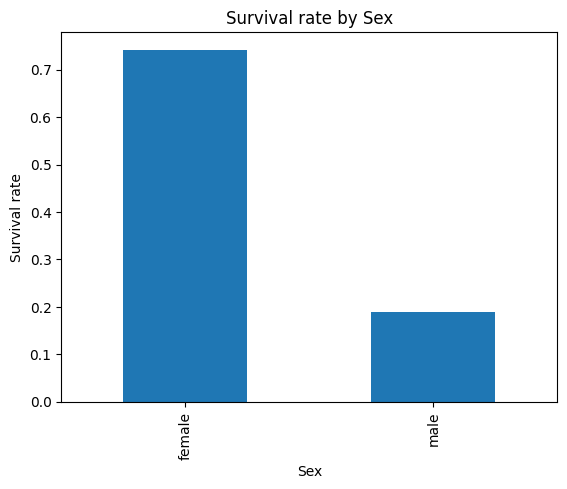

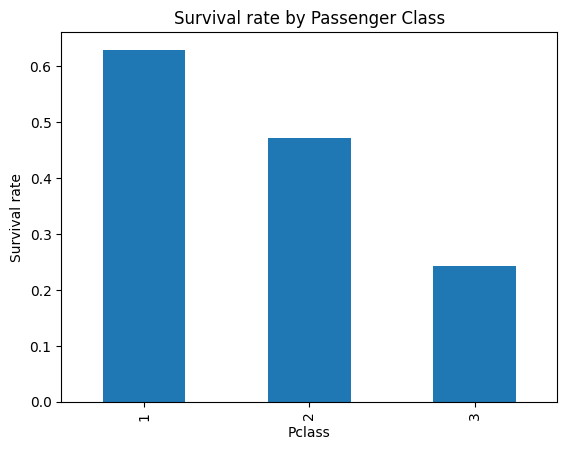

In [14]:
# Cell 4: simple plots (optional)

import matplotlib.pyplot as plt

# Survived by Sex
train_df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival rate by Sex")
plt.ylabel("Survival rate")
plt.show()

# Survived by Pclass
train_df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Survival rate by Passenger Class")
plt.ylabel("Survival rate")
plt.show()


In [15]:
# Cell 5: feature selection and preprocessing functions

FEATURE_COLS = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
TARGET_COL = "Survived"

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Basic preprocessing: select columns, fill missing, encode categoricals."""
    df = df.copy()

    # Keep only the columns we care about (some might not exist in test)
    cols = [c for c in FEATURE_COLS if c in df.columns]
    df = df[cols]

    # Fill missing numeric values with median
    numeric_cols = ["Age", "SibSp", "Parch", "Fare"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Fill missing Embarked with mode
    if "Embarked" in df.columns:
        df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # One-hot encode categoricals (Sex, Embarked)
    df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

    return df


In [16]:
# Cell 6: create train/validation sets

X = preprocess(train_df)
y = train_df[TARGET_COL]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)


X_train shape: (712, 8)
X_val shape  : (179, 8)


In [17]:
# Cell 7: train a basic RandomForest model

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"Validation accuracy: {val_acc:.4f}")
print("\nClassification report:")
print(classification_report(y_val, y_val_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_val_pred))


Validation accuracy: 0.7933

Classification report:
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       110
           1       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179


Confusion matrix:
[[101   9]
 [ 28  41]]


In [18]:
# Cell 8: train on full training data and create a submission file

# Fit on all available labeled data
rf_full = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
)
rf_full.fit(X, y)

# Preprocess test data with the same function
X_test = preprocess(test_df)

# Align test columns with train (in case get_dummies created differences)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

test_preds = rf_full.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_preds.astype(int),
})

submission.head()


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [19]:
# Cell 9: save submission to reports or root

OUTPUT_PATH = PROJECT_ROOT / "reports" / "titanic_submission.csv"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

submission.to_csv(OUTPUT_PATH, index=False)

print("Saved submission to:", OUTPUT_PATH)


Saved submission to: C:\Users\surbhi.prasad\Documents\Projects\mlops_ai_monitoring\reports\titanic_submission.csv
